<a href="https://colab.research.google.com/github/Slautin/2026_domain_growth_hypothesis_learning/blob/main/04042026_Symbolic_regression_Domain_growth_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install aespm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.9/223.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.0/161.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you h

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import rand

import h5py
import os

In [2]:
import json
import sympy
from sympy import sympify
from sympy import lambdify

import aespm.tools as at

In [3]:
def _encode(value):
    """Return (kind, payload) so we know how to write and later restore."""
    if isinstance(value, tuple):
        return "tuple_json", json.dumps(list(value))
    if isinstance(value, (int, float, bool, str)):
        return "scalar", value
    if isinstance(value, np.ndarray):
        return "ndarray", value
    if isinstance(value, list):
        if all(isinstance(v, str) for v in value):
            return "list_str", value
        if all(isinstance(v, np.ndarray) for v in value):
            return "list_ndarray", value
        if all(hasattr(v, 'free_symbols') for v in value):
            return "list_sympy", [str(v) for v in value]
        # fall back: try JSON (only safe for plain Python scalars)
        return "list_json", json.dumps(value)
    # sympy expression
    if hasattr(value, 'free_symbols') or hasattr(value, 'is_symbol'):
        return "sympy", str(value)
    raise TypeError(f"Unsupported type: {type(value)}")


# ── save ─────────────────────────────────────────────────────────────────────

def save_dict_to_h5(data: dict, filepath: str) -> None:
    """
    Save *data* dict to an HDF5 file at *filepath*.
    Existing file is overwritten.
    """
    with h5py.File(filepath, "w") as f:
        for key, value in data.items():
            kind, payload = _encode(value)

            if kind == "ndarray":
                ds = f.create_dataset(key, data=payload)
                ds.attrs["kind"] = kind

            elif kind == "list_ndarray":
                grp = f.create_group(key)
                grp.attrs["kind"] = kind
                for i, arr in enumerate(payload):
                    grp.create_dataset(str(i), data=arr)

            elif kind == "list_str":
                dt = h5py.special_dtype(vlen=str)
                ds = f.create_dataset(key, data=np.array(payload, dtype=object), dtype=dt)
                ds.attrs["kind"] = kind

            elif kind == "list_sympy":
                dt = h5py.special_dtype(vlen=str)
                ds = f.create_dataset(key, data=np.array(payload, dtype=object), dtype=dt)
                ds.attrs["kind"] = kind

            elif kind in ("scalar", "tuple_json", "list_json", "sympy"):
                # store as a scalar / string dataset
                if isinstance(payload, str):
                    ds = f.create_dataset(key, data=payload)
                else:
                    ds = f.create_dataset(key, data=payload)
                ds.attrs["kind"] = kind

            else:
                raise ValueError(f"Unknown kind: {kind}")

    print(f"Saved {len(data)} keys → {filepath}")


# ── load ─────────────────────────────────────────────────────────────────────

def load_dict_from_h5(filepath: str) -> dict:
    """
    Load a dict previously saved with *save_dict_to_h5*.
    Sympy expressions are reconstructed with sympify.
    """
    result = {}
    with h5py.File(filepath, "r") as f:
        for key in f.keys():
            item = f[key]
            kind = item.attrs.get("kind", "ndarray")

            if kind == "ndarray":
                result[key] = item[()]

            elif kind == "list_ndarray":
                n = len(item)
                result[key] = [item[str(i)][()] for i in range(n)]

            elif kind == "list_str":
                raw = item[()]
                result[key] = [v.decode() if isinstance(v, bytes) else v for v in raw]

            elif kind == "tuple_json":
                result[key] = tuple(json.loads(item[()]))

            elif kind == "list_json":
                result[key] = json.loads(item[()])

            elif kind == "list_sympy":
                raw = item[()]
                result[key] = [sympify(v.decode() if isinstance(v, bytes) else v) for v in raw]

            elif kind == "sympy":
                result[key] = sympify(item[()])

            elif kind == "scalar":
                val = item[()]
                result[key] = val.item() if isinstance(val, np.generic) else val

            else:
                # best-effort fallback
                result[key] = item[()]

    return result

In [4]:
!gdown https://drive.google.com/file/d/19gi4lrTiM2PJqx7eJ2tJ2QT5OUz00_ZG/view?usp=sharing --fuzzy

Downloading...
From: https://drive.google.com/uc?id=19gi4lrTiM2PJqx7eJ2tJ2QT5OUz00_ZG
To: /content/04012026exp3.h5
100% 604k/604k [00:00<00:00, 14.4MB/s]


In [5]:
!gdown https://drive.google.com/file/d/1daUogLaQJjWqOIHNfqoXQjCLrHiiAeyB/view?usp=sharing --fuzzy

Downloading...
From (original): https://drive.google.com/uc?id=1daUogLaQJjWqOIHNfqoXQjCLrHiiAeyB
From (redirected): https://drive.google.com/uc?id=1daUogLaQJjWqOIHNfqoXQjCLrHiiAeyB&confirm=t&uuid=193d4b8f-7ff6-4305-b556-791a1ef9596b
To: /content/260401.zip
100% 54.3M/54.3M [00:01<00:00, 54.1MB/s]


In [6]:
!unzip /content/260401.zip

Archive:  /content/260401.zip
   creating: 260401/
  inflating: __MACOSX/._260401       
  inflating: 260401/PZT_0263.ibw     
  inflating: __MACOSX/260401/._PZT_0263.ibw  
  inflating: 260401/PZT_0277.ibw     
  inflating: __MACOSX/260401/._PZT_0277.ibw  
  inflating: 260401/PZT_0288.ibw     
  inflating: __MACOSX/260401/._PZT_0288.ibw  
  inflating: 260401/PZT_0289.ibw     
  inflating: __MACOSX/260401/._PZT_0289.ibw  
  inflating: 260401/PZT_0276.ibw     
  inflating: __MACOSX/260401/._PZT_0276.ibw  
  inflating: 260401/PZT_0262.ibw     
  inflating: __MACOSX/260401/._PZT_0262.ibw  
  inflating: 260401/PZT_0248.ibw     
  inflating: __MACOSX/260401/._PZT_0248.ibw  
  inflating: 260401/PZT_0274.ibw     
  inflating: __MACOSX/260401/._PZT_0274.ibw  
  inflating: 260401/PZT_0260.ibw     
  inflating: __MACOSX/260401/._PZT_0260.ibw  
  inflating: 260401/PZT_0261.ibw     
  inflating: __MACOSX/260401/._PZT_0261.ibw  
  inflating: 260401/PZT_0275.ibw     
  inflating: __MACOSX/260401/._PZ

In [7]:
res = load_dict_from_h5('/content/04012026exp3.h5')
folder_scans = r'/content/260401/'

In [8]:
res.keys()

dict_keys(['LLM_res', 'LLM_score', 'SR_complexity', 'SR_equations', 'SR_loss', 'SR_score', 'area_m', 'area_px', 'binary_masks', 'duration_range', 'eff_radius_m', 'errors', 'n_iter', 'n_seeds', 'param_seq', 'scan_names', 'voltage_range'])

In [9]:
np.argmax(np.array(res['LLM_score'][0])), np.argmax(np.array(res['SR_score'][0]))

(4, 4)

In [10]:
res['SR_equations'][0]

['0.012240856',
 'x0 * 0.021559497',
 'relu(x0 + -1.5600995)',
 '((x0 + x1) - 2.7683594) * 0.008496621',
 'relu(((x0 + x1) - 4.5926986) * 0.017546348)']

In [11]:
import re
import sympy as sp
from sympy.parsing.sympy_parser import parse_expr

x0, x1 = sp.symbols('x0 x1')

def relu(z):
    return sp.Max(0, z)

def clean_eq(eq):
    eq = re.sub(r'-\s*-', '+ ', eq)
    eq = re.sub(r'\+\s*-', '- ', eq)
    eq = re.sub(r'-\s*\+', '- ', eq)
    eq = re.sub(r'\+\s*\+', '+ ', eq)
    return eq

def round_expr(expr, ndigits=6):
    return expr.xreplace({
        n: sp.Float(round(float(n), ndigits))
        for n in expr.atoms(sp.Number)
    })

def make_label(eq, ndigits=3):
    eq = clean_eq(eq)

    #print(eq)

    expr = parse_expr(
        eq,
        local_dict={
            'x0': x0,
            'x1': x1,
            'sqrt': sp.sqrt,
            'log': sp.log,
            'relu': relu,
        },
        evaluate=True
    )

    expr = round_expr(expr, ndigits)

    #expr = sp.factor(expr)   # keeps compact structure better
    expr = expr.subs({x0: sp.Symbol('t'), x1: sp.Symbol('V')})

    latex = sp.latex(expr)
    latex = latex.replace(r"\max\left(0.0,", r"\mathrm{ReLU}\left(")
    latex = latex.replace(r"\max\left(0.0,", r"\mathrm{ReLU}\left(")

    return f"${latex}$"

In [12]:
import sympy as sp
from sympy.parsing.sympy_parser import parse_expr

def round_expr(expr, ndigits=3):
    return expr.xreplace({
        n: sp.Float(round(float(n), ndigits))
        for n in expr.atoms(sp.Number)
    })

x1 = sp.Symbol('x1')

eq = '(x1 * 0.0066790325) - -0.00024316934'
eq = clean_eq(eq)



expr = parse_expr(eq, local_dict={'x1': x1}, evaluate=True)
expr = round_expr(expr, 4)
print(expr)
print(sp.latex(expr))

0.0067*x1 + 0.0002
0.0067 x_{1} + 0.0002


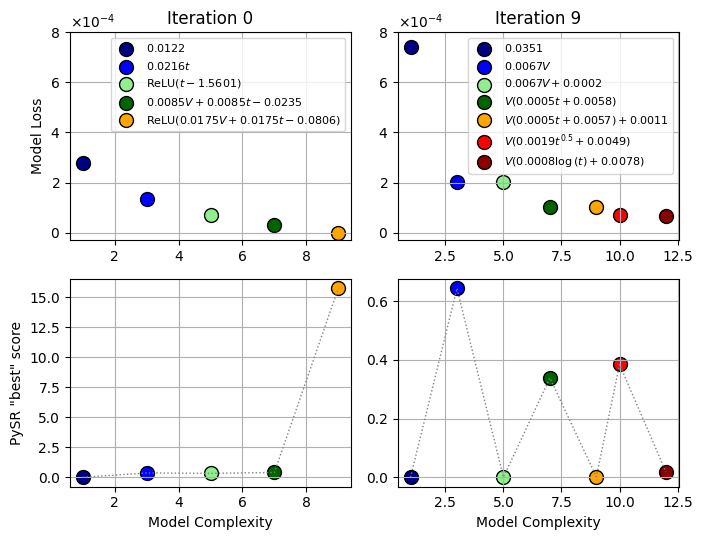

In [29]:
import matplotlib.ticker as ticker


colors = ['navy', 'blue', 'lightgreen', 'darkgreen', 'orange', 'red', 'darkred']

fig, ax = plt.subplots(2, 2, figsize=(7, 5.5))

for _ in ax[0]:
    _.grid()
    _.set_ylim(-0.3e-4, 8e-4)

    _.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    _.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))


eqs = res['SR_equations'][0]
for j,ii in enumerate(np.arange(len(eqs))):
  labels = [make_label(eq, ndigits=4) for eq in eqs]

  ax[0,0].scatter(res['SR_complexity'][0][ii], res['SR_loss'][0][ii],  c=colors[j], s=100, edgecolor='k', lw=1, label = labels[ii])
  ax[1,0].scatter(res['SR_complexity'][0][ii], res['SR_score'][0][ii], c=colors[j], s=100, edgecolor='k', lw=1, label = labels[ii])
ax[1,0].plot(res['SR_complexity'][0], res['SR_score'][0], ':', c='gray',lw=1)
ax[0,0].legend(fontsize=8)

eqs = res['SR_equations'][-1]
for j,ii in enumerate(np.arange(len(eqs))):
  labels = [make_label(eq, ndigits=4) for eq in eqs]

  ax[0,1].scatter(res['SR_complexity'][-1][ii], res['SR_loss'][-1][ii], c=colors[j], s=100, edgecolor='k', lw=1, label = labels[ii])
  ax[1,1].scatter(res['SR_complexity'][-1][ii], res['SR_score'][-1][ii], c=colors[j], s=100, edgecolor='k', lw=1, label = labels[ii])
ax[1,1].plot(res['SR_complexity'][-1], res['SR_score'][-1], ':', c='gray',lw=1)
ax[0,1].legend(fontsize=8)

ax[0,0].set_title('Iteration 0')
ax[0,1].set_title('Iteration 9')

ax[0,0].set_ylabel('Model Loss')
ax[1,0].set_ylabel('PySR "best" score')


for _ in ax[1]:
  _.set_xlabel('Model Complexity')
  _.grid()


plt.tight_layout()

fig.savefig('fig3.jpg', dpi=300, bbox_inches='tight')

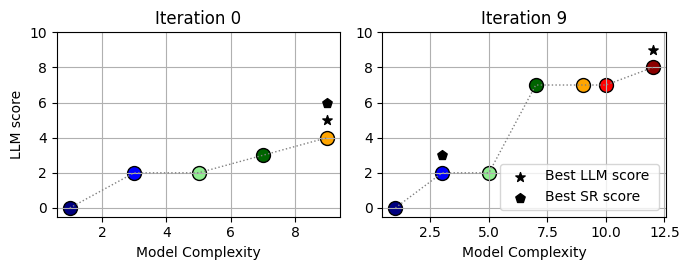

In [34]:
colors = ['navy', 'blue', 'lightgreen', 'darkgreen', 'orange', 'red', 'darkred']

best_llm_idx_0 = np.argmax(res['LLM_score'][0])
best_pysr_idx_0 = np.argmax(res['SR_score'][0])

best_llm_idx_last = np.argmax(res['LLM_score'][-1])
best_pysr_idx_last = np.argmax(res['SR_score'][-1])

fig, ax = plt.subplots(1, 2, figsize=(7, 2.8))

eqs = res['SR_equations'][0]
labels = [make_label(eq, ndigits=4) for eq in eqs]

for j, ii in enumerate(np.arange(len(eqs))):
    x = res['SR_complexity'][0][ii]
    y = res['LLM_score'][0][ii]

    ax[0].scatter(
        x, y,
        c=colors[j],
        s=100,
        edgecolor='k',
        lw=1,
        label=labels[ii]
    )

    # ⭐ best LLM
    if ii == best_llm_idx_0:
        ax[0].scatter(
            x, y+1,
            marker='*',
            s=50,
            c='k',
            zorder=5
        )

    # ✖ best PySR
    if ii == best_pysr_idx_0:
        ax[0].scatter(
            x, y+2,
            marker='p',
            s=50,
            c='black',
            zorder=5
        )
ax[0].plot(res['SR_complexity'][0], res['LLM_score'][0], ':', c='gray', lw=1)
#ax[0].legend(fontsize=8)
ax[0].set_title('Iteration 0')

eqs = res['SR_equations'][-1]
labels = [make_label(eq, ndigits=4) for eq in eqs]

for j, ii in enumerate(np.arange(len(eqs))):
    x = res['SR_complexity'][-1][ii]
    y = res['LLM_score'][-1][ii]

    ax[1].scatter(
        x, y,
        c=colors[j],
        s=100,
        edgecolor='k',
        lw=1,
        #label=labels[ii]
    )

    # ⭐ best LLM
    if ii == best_llm_idx_last:
        ax[1].scatter(
            x, y+1,
            marker='*',
            s=50,
            c='k',
            zorder=5
        )

    # ✖ best PySR
    if ii == best_pysr_idx_last:
        ax[1].scatter(
            x, y+1,
            marker='p',
            s=50,
            c='black',
            zorder=5
        )

ax[1].plot(res['SR_complexity'][-1], res['LLM_score'][-1], ':', c='gray', lw=1)
#ax[1].legend(fontsize=8)
ax[1].set_title('Iteration 9')

ax[0].set_ylabel('LLM score')

ax[1].scatter([], [], marker='*', s=50, c='black', label='Best LLM score ')
ax[1].scatter([], [], marker='p', s=50, c='black', label='Best SR score')
ax[1].legend(fontsize=10)

for _ in ax:
    _.set_xlabel('Model Complexity')
    _.grid()
    _.set_ylim(-.5, 10)

plt.tight_layout()

fig.savefig('fig5.jpg', dpi=300, bbox_inches='tight')

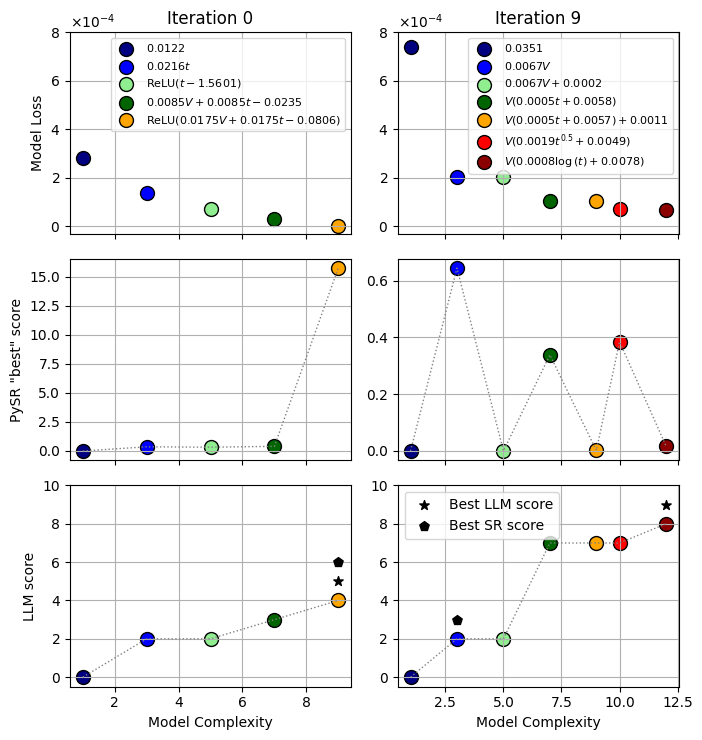

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

colors = ['navy', 'blue', 'lightgreen', 'darkgreen', 'orange', 'red', 'darkred']

iter_ids = [0, -1]
iter_titles = ['Iteration 0', 'Iteration 9']

best_llm_idx = {
    0: np.argmax(res['LLM_score'][0]),
    -1: np.argmax(res['LLM_score'][-1]),
}

best_pysr_idx = {
    0: np.argmax(res['SR_score'][0]),
    -1: np.argmax(res['SR_score'][-1]),
}

fig, ax = plt.subplots(
    3, 2,
    figsize=(7, 7.5),
    sharex='col'
)

# =========================
# Plot rows:
# 0 — SR loss
# 1 — PySR score
# 2 — LLM score
# =========================
for col, iter_id in enumerate(iter_ids):

    eqs = res['SR_equations'][iter_id]
    labels = [make_label(eq, ndigits=4) for eq in eqs]

    complexity = res['SR_complexity'][iter_id]
    sr_loss = res['SR_loss'][iter_id]
    sr_score = res['SR_score'][iter_id]
    llm_score = res['LLM_score'][iter_id]

    for j, ii in enumerate(np.arange(len(eqs))):

        color = colors[j % len(colors)]

        # -------------------------
        # Row 0: SR loss
        # -------------------------
        ax[0, col].scatter(
            complexity[ii],
            sr_loss[ii],
            c=color,
            s=100,
            edgecolor='k',
            lw=1,
            label=labels[ii]
        )

        # -------------------------
        # Row 1: PySR score
        # -------------------------
        ax[1, col].scatter(
            complexity[ii],
            sr_score[ii],
            c=color,
            s=100,
            edgecolor='k',
            lw=1
        )

        # -------------------------
        # Row 2: LLM score
        # -------------------------
        x = complexity[ii]
        y = llm_score[ii]

        ax[2, col].scatter(
            x,
            y,
            c=color,
            s=100,
            edgecolor='k',
            lw=1
        )

        # Best LLM score
        if ii == best_llm_idx[iter_id]:
            ax[2, col].scatter(
                x,
                y + 1,
                marker='*',
                s=50,
                c='k',
                zorder=5
            )

        # Best PySR score
        if ii == best_pysr_idx[iter_id]:
            ax[2, col].scatter(
                x,
                y + 2 if iter_id == 0 else y + 1,
                marker='p',
                s=50,
                c='black',
                zorder=5
            )

    # Connecting lines
    ax[1, col].plot(
        complexity,
        sr_score,
        ':',
        c='gray',
        lw=1
    )

    ax[2, col].plot(
        complexity,
        llm_score,
        ':',
        c='gray',
        lw=1
    )

    # Titles
    ax[0, col].set_title(iter_titles[col])

# =========================
# Formatting
# =========================

# Loss row formatting
for _ax in ax[0]:
    _ax.grid()
    _ax.set_ylim(-0.3e-4, 8e-4)
    _ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    _ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Other rows
for row in [1, 2]:
    for _ax in ax[row]:
        _ax.grid()

# LLM score limits
for _ax in ax[2]:
    _ax.set_ylim(-0.5, 10)

# Axis labels
ax[0, 0].set_ylabel('Model Loss')
ax[1, 0].set_ylabel('PySR "best" score')
ax[2, 0].set_ylabel('LLM score')

for _ax in ax[2]:
    _ax.set_xlabel('Model Complexity')

# Legends
ax[0, 0].legend(fontsize=8)
ax[0, 1].legend(fontsize=8)

ax[2, 1].scatter([], [], marker='*', s=50, c='black', label='Best LLM score')
ax[2, 1].scatter([], [], marker='p', s=50, c='black', label='Best SR score')
ax[2, 1].legend(fontsize=10)


plt.tight_layout()
plt.show()

fig.savefig('fig4.jpg', dpi=300, bbox_inches='tight')

In [16]:


def make_symbolic_model(model_str: str):
  x0, x1 = symbols('x0 x1')

  expr = parse_expr(
          model_str,
          local_dict={
              'x0': x0,
              'x1': x1,
              'sqrt': sp.sqrt,
              'log': sp.log,
              'relu': relu,
          },
          evaluate=True
      )

  f = sp.lambdify(
          (x0, x1),
          expr,
          modules=[{'Max': np.maximum,'relu': np.maximum}, 'numpy']
      )
  return f

In [17]:
from sympy import symbols

duration_min, duration_max = res['duration_range']
voltage_min, voltage_max = res['voltage_range']

n_iter = res['n_iter']
n_seeds = res['n_seeds']
X = res['param_seq']
R = res['eff_radius_m']*1e6
models = res['SR_equations']

pps = int((len(R) - n_seeds[0]) / n_iter[0])

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


def predict_model(f, X):
    """
    Evaluate symbolic model on X of shape (N, 2).
    Handles constant models by broadcasting scalar output.
    """
    X = np.asarray(X, dtype=float)
    y_pred = f(*X.T)

    if np.isscalar(y_pred):
        y_pred = np.full(X.shape[0], y_pred, dtype=float)
    else:
        y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    return y_pred


def evaluate_models(models_dict, X_train, y_train, X_test, y_test):
    """
    Evaluate a dictionary of models on train/test splits.
    Returns two dicts with MSE values.
    """
    mse_train = {}
    mse_test = {}

    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    y_train = np.asarray(y_train, dtype=float).reshape(-1)
    y_test = np.asarray(y_test, dtype=float).reshape(-1)

    for name, f in models_dict.items():
        y_pred_train = predict_model(f, X_train)
        y_pred_test = predict_model(f, X_test)

        if len(y_pred_train) != len(y_train):
            raise ValueError(
                f"{name}: train prediction length {len(y_pred_train)} != y_train length {len(y_train)}"
            )
        if len(y_pred_test) != len(y_test):
            raise ValueError(
                f"{name}: test prediction length {len(y_pred_test)} != y_test length {len(y_test)}"
            )

        mse_train[name] = mean_squared_error(y_train, y_pred_train)
        mse_test[name] = mean_squared_error(y_test, y_pred_test)

    return mse_train, mse_test


def build_models_for_stage(stage_idx, models, res, make_symbolic_model):
    """
    Build best-loss, best-PySR-score, and best-LLM-score models for a given stage.

    Assumes:
      models[stage_idx] -> list of model strings
      res['SR_loss'][stage_idx] -> losses for those models
      res['SR_score'][stage_idx] -> PySR scores
      res['LLM_score'][stage_idx] -> LLM scores
    """
    return {
        'best_loss': make_symbolic_model(
            models[stage_idx][np.argmin(res['SR_loss'][stage_idx])]
        ),
        'best_pysr': make_symbolic_model(
            models[stage_idx][np.argmax(res['SR_score'][stage_idx])]
        ),
        'best_llm': make_symbolic_model(
            models[stage_idx][np.argmax(res['LLM_score'][stage_idx])]
        ),
    }

In [19]:
def plot_stagewise_mse_extended(
    X,
    y,
    models,
    res,
    make_symbolic_model,
    stage_list,
    n_seed=5,
    points_per_iter=5,
):
    import numpy as np
    import matplotlib.pyplot as plt

    keys = ['best_loss', 'best_pysr', 'best_llm']
    labels = ['SR loss', 'SR score', 'LLM score']
    colors = ['dimgray', 'tab:blue', 'tab:orange']

    results_train = {k: [] for k in keys}
    results_test = {k: [] for k in keys}
    used_stages = []

    for stage_idx in stage_list:
        n_train = n_seed + points_per_iter * stage_idx

        if n_train <= 0 or n_train >= len(X):
            continue

        X_train = X[:n_train]
        y_train = y[:n_train]
        X_test = X[n_train:]
        y_test = y[n_train:]

        if len(X_test) == 0:
            continue

        models_by_stage = {
            'best_loss': make_symbolic_model(
                models[stage_idx][np.argmin(res['SR_loss'][stage_idx])]
            ),
            'best_pysr': make_symbolic_model(
                models[stage_idx][np.argmax(res['SR_score'][stage_idx])]
            ),
            'best_llm': make_symbolic_model(
                models[stage_idx][np.argmax(res['LLM_score'][stage_idx])]
            ),
        }

        mse_train, mse_test = evaluate_models(
            models_by_stage, X_train, y_train, X_test, y_test
        )

        for k in keys:
            results_train[k].append(mse_train[k])
            results_test[k].append(mse_test[k])

        used_stages.append(stage_idx)

    # Convert to arrays
    train_vals = {k: np.array(results_train[k]) for k in keys}
    test_vals = {k: np.array(results_test[k]) for k in keys}

    # Aggregates for bar plots
    train_means = [np.mean(train_vals[k]) for k in keys]
    train_stds = [np.std(train_vals[k]) for k in keys]

    test_means = [np.mean(test_vals[k]) for k in keys]
    test_stds = [np.std(test_vals[k]) for k in keys]

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(2, 2, figsize=(7, 5.5), sharey='row')

    # =========================
    # Top row: evolution vs iteration
    # =========================
    for i, k in enumerate(keys):
        ax[0, 0].plot(used_stages, train_vals[k], '-o', label=labels[i], color=colors[i])
        ax[0, 1].plot(used_stages, test_vals[k], '-o', label=labels[i], color=colors[i])

    ax[0, 0].set_title('Available points')
    ax[0, 1].set_title('Subsequently acquired data')

    ax[0, 0].set_ylabel('Mean squared error')
    ax[0, 0].set_xlabel('Iteration')
    ax[0, 1].set_xlabel('Iteration')

    ax[0, 1].legend(frameon=True)

    # =========================
    # Bottom row: aggregated bars
    # =========================
    x = np.arange(len(labels))

    ax[1, 0].bar(x, train_means, yerr=train_stds, capsize=4, color=colors)
    ax[1, 0].set_xticks(x)
    ax[1, 0].set_xticklabels(labels, rotation=20)
    #ax[1, 0].set_title('Measured data available at selection')
    ax[1, 0].set_ylabel('Mean squared error')

    ax[1, 1].bar(x, test_means, yerr=test_stds, capsize=4, color=colors)
    ax[1, 1].set_xticks(x)
    ax[1, 1].set_xticklabels(labels, rotation=20)
    #ax[1, 1].set_title('Subsequently acquired measurements')

    # Panel labels
    # ax[0, 0].text(-0.15, 1.05, 'a', transform=ax[0, 0].transAxes, fontweight='bold')
    # ax[0, 1].text(-0.15, 1.05, 'b', transform=ax[0, 1].transAxes, fontweight='bold')
    # ax[1, 0].text(-0.15, 1.05, 'c', transform=ax[1, 0].transAxes, fontweight='bold')
    # ax[1, 1].text(-0.15, 1.05, 'd', transform=ax[1, 1].transAxes, fontweight='bold')

    for _ in ax.flatten():
      _.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
      _.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    for _ in ax[0]:
      _.grid()

    plt.tight_layout()
    return fig, ax

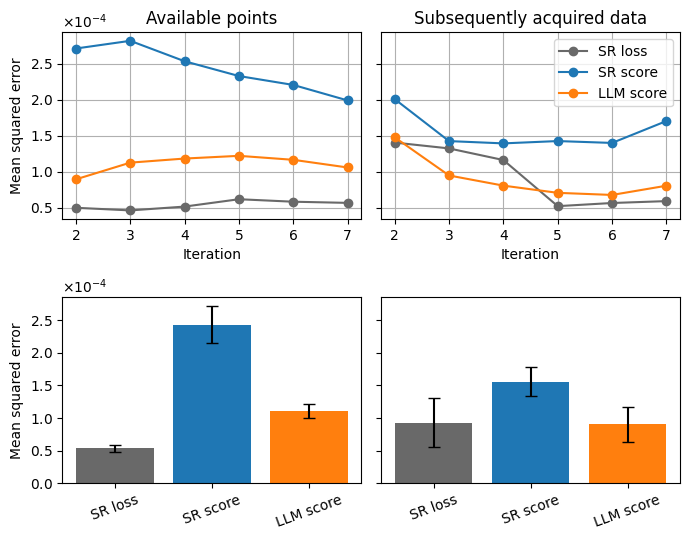

In [32]:
fig, ax = plot_stagewise_mse_extended(
    X=X,
    y=R,
    models=models,
    res=res,
    make_symbolic_model=make_symbolic_model,
    stage_list=[2, 3, 4, 5, 6, 7],
    n_seed=5,
    points_per_iter=5,
)
plt.show()

fig.savefig('fig6.jpg', dpi=300, bbox_inches='tight')

In [27]:
models[-1]

['0.035066187',
 'x1 * 0.0067113936',
 '(x1 * 0.0066790325) - -0.00024316934',
 '((x0 * 0.00051602244) - -0.0058029047) * x1',
 '(((x0 * 0.00051749835) - -0.005654421) * x1) + 0.0010969313',
 '((sqrt(x0) * 0.0019357918) - -0.004926216) * x1',
 '((log(x0) * 0.0007866032) - -0.0078091975) * x1']

In [22]:
V_vals = np.linspace(voltage_min, voltage_max, int(1e2))
t_vals = np.linspace(np.log(duration_min), np.log(duration_max), int(1e2))

# Meshgrid
TT, VV = np.meshgrid(t_vals, V_vals, indexing="xy")

# Flatten for model input
X_grid = np.column_stack([TT.ravel(), VV.ravel()])
X_grid[:, 0] = np.exp(X_grid[:,0])

In [114]:
f = make_symbolic_model(models[-1][-1])

f0 = make_symbolic_model(models[0][-1])

Text(0, 0.5, 'Voltage, V')

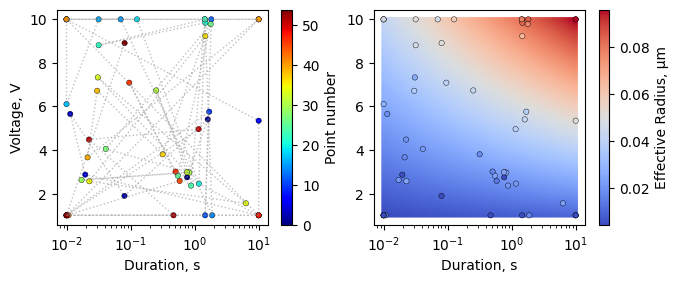

In [115]:
pred = f(*X_grid.T)

fig, ax = plt.subplots(1, 2, figsize=(7.5,2.8))

for _ in ax:
  _.set_xlabel('Duration, s')
  _.set_xscale('log')

im0 = ax[0].scatter(*X.T, s=15, lw=.3, ec='k', cmap='jet', c=np.arange(len(X)))
ax[0].plot(*X.T, ':', color='gray', alpha=0.5, lw=1)
cbar = plt.colorbar(im0, label='Point number')
ax[1].scatter(*X_grid.T, c=pred, s=5, cmap='coolwarm', vmin=np.min(pred), vmax=np.max(pred))
im1 = ax[1].scatter(*X.T, c=R, s=15, lw=.3, ec='k', cmap='coolwarm', vmin=np.min(pred), vmax=np.max(pred))

cbar = plt.colorbar(im1, label='Effective Radius, µm')

ax[0].set_ylabel('Voltage, V')



In [116]:
pred

array([0.00418676, 0.00424164, 0.00429653, ..., 0.09510647, 0.09565533,
       0.09620418])

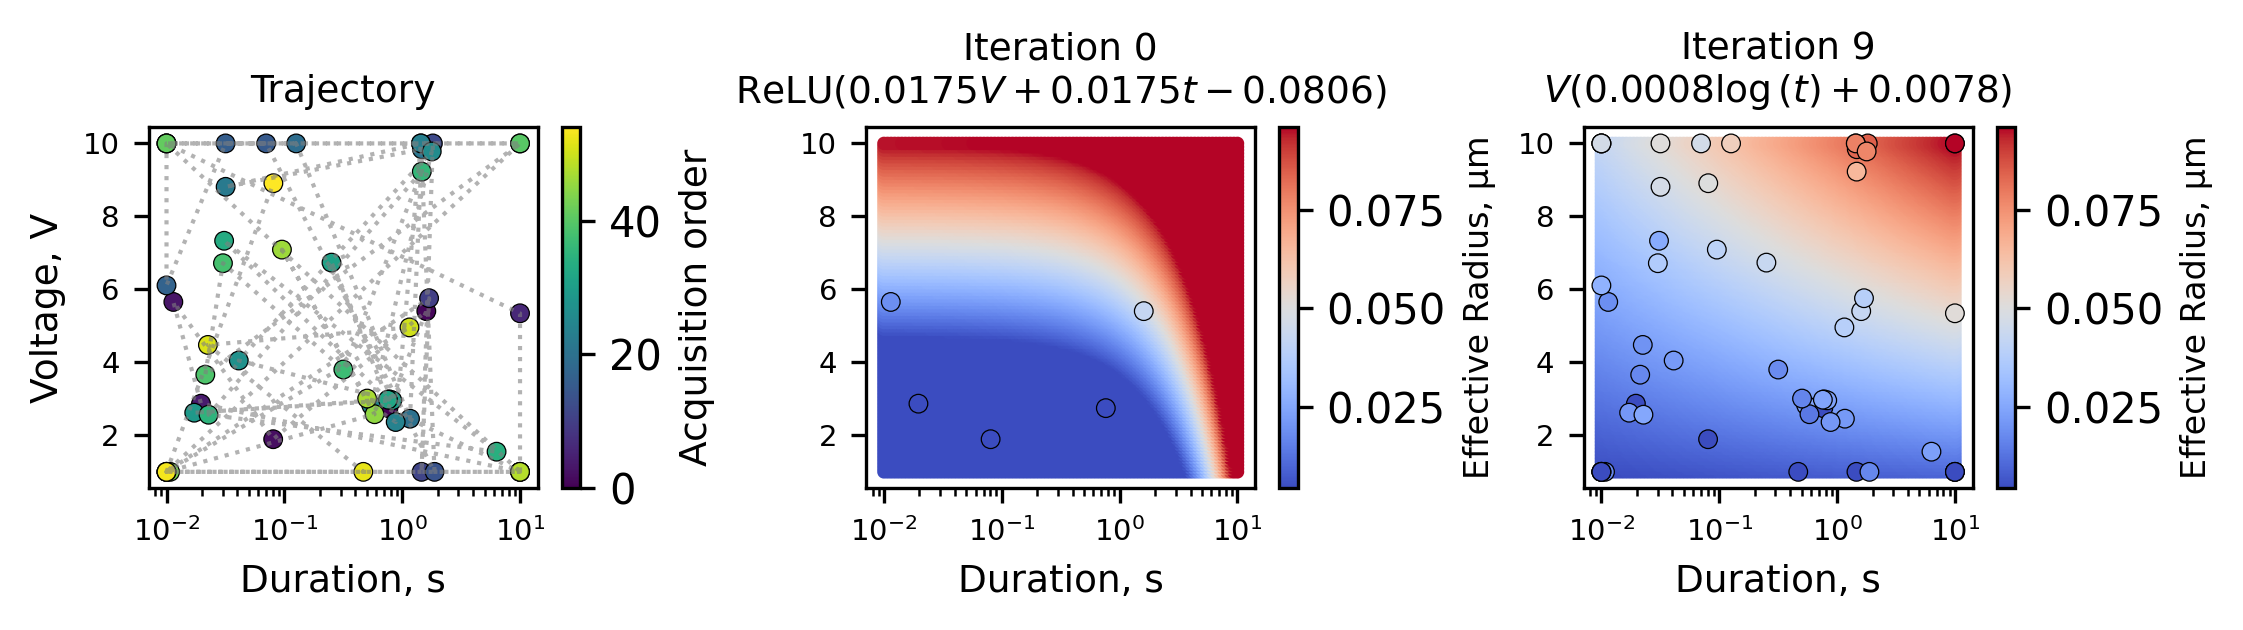

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Inputs you already have:
# X       -> (N, 2) [duration, voltage]
# R       -> (N,)
# X_grid  -> grid for visualization
# f       -> final model
# f0      -> model after iteration 0 (early model)
# ------------------------------------------------------------

# Predictions
pred_final = f(*X_grid.T)
pred_early = f0(*X_grid.T)

eqs_early = res['SR_equations'][0][-1]
eqs_final = res['SR_equations'][-1][-1]
label_early = make_label(eqs_early, ndigits=4)
label_final = make_label(eqs_final, ndigits=4)

# Split for "available data" (early stage)
n_seed = 5
points_per_iter = 5
early_iter = 0   # you can change this

n_train = n_seed + points_per_iter * early_iter

X_early = X[:n_train]
R_early = R[:n_train]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(7.5, 2.2), dpi=300)

for _ in ax:
    _.set_xlabel('Duration, s', fontsize=9)
    _.set_xscale('log')

# =========================
# (a) Trajectory
# =========================
im0 = ax[0].scatter(
    X[:, 0], X[:, 1],
    s=20, lw=0.3, ec='k',
    c=np.arange(len(X)),
    cmap='viridis'
)

ax[0].plot(X[:, 0], X[:, 1], ':', color='gray', alpha=0.6, lw=1)

cbar0 = plt.colorbar(im0, ax=ax[0])
cbar0.set_label('Acquisition order', fontsize=9)

ax[0].set_title('Trajectory', fontsize=9)
ax[0].set_ylabel('Voltage, V', fontsize=9)

# =========================
# (b) Early model + data
# =========================
ax[1].scatter(
    X_grid[:, 0], X_grid[:, 1],
    c=pred_early,
    s=5,
    cmap='coolwarm',
    vmin=np.min(pred_final),
    vmax=np.max(pred_final)
)

im1 = ax[1].scatter(
    X_early[:, 0], X_early[:, 1],
    c=R_early,
    s=20, lw=0.3, ec='k',
    cmap='coolwarm',
    vmin=np.min(pred_final),
    vmax=np.max(pred_final)
)
cbar = plt.colorbar(im1, ax=ax[1])
cbar.set_label('Effective Radius, µm', fontsize=8)

ax[1].set_title(f'Iteration 0\n{label_early}', fontsize=9)

# =========================
# (c) Final model + data
# =========================
ax[2].scatter(
    X_grid[:, 0], X_grid[:, 1],
    c=pred_final,
    s=5,
    cmap='coolwarm',
    vmin=np.min(pred_final),
    vmax=np.max(pred_final)
)

im2 = ax[2].scatter(
    X[:, 0], X[:, 1],
    c=R,
    s=20, lw=0.3, ec='k',
    cmap='coolwarm',
    vmin=np.min(pred_final),
    vmax=np.max(pred_final)
)

ax[2].set_title(f'Iteration 9\n{label_final}', fontsize=9)
ax[0].tick_params(axis='both', labelsize=7)
ax[1].tick_params(axis='both', labelsize=7)
ax[2].tick_params(axis='both', labelsize=7)

# Shared colorbar for radius
cbar = plt.colorbar(im2, ax=ax[2])
cbar.set_label('Effective Radius, µm', fontsize=8)

plt.tight_layout()
plt.show()

In [151]:
models[-1]

['0.035066187',
 'x1 * 0.0067113936',
 '(x1 * 0.0066790325) - -0.00024316934',
 '((x0 * 0.00051602244) - -0.0058029047) * x1',
 '(((x0 * 0.00051749835) - -0.005654421) * x1) + 0.0010969313',
 '((sqrt(x0) * 0.0019357918) - -0.004926216) * x1',
 '((log(x0) * 0.0007866032) - -0.0078091975) * x1']

In [121]:
X_grid.shape

(10000, 2)

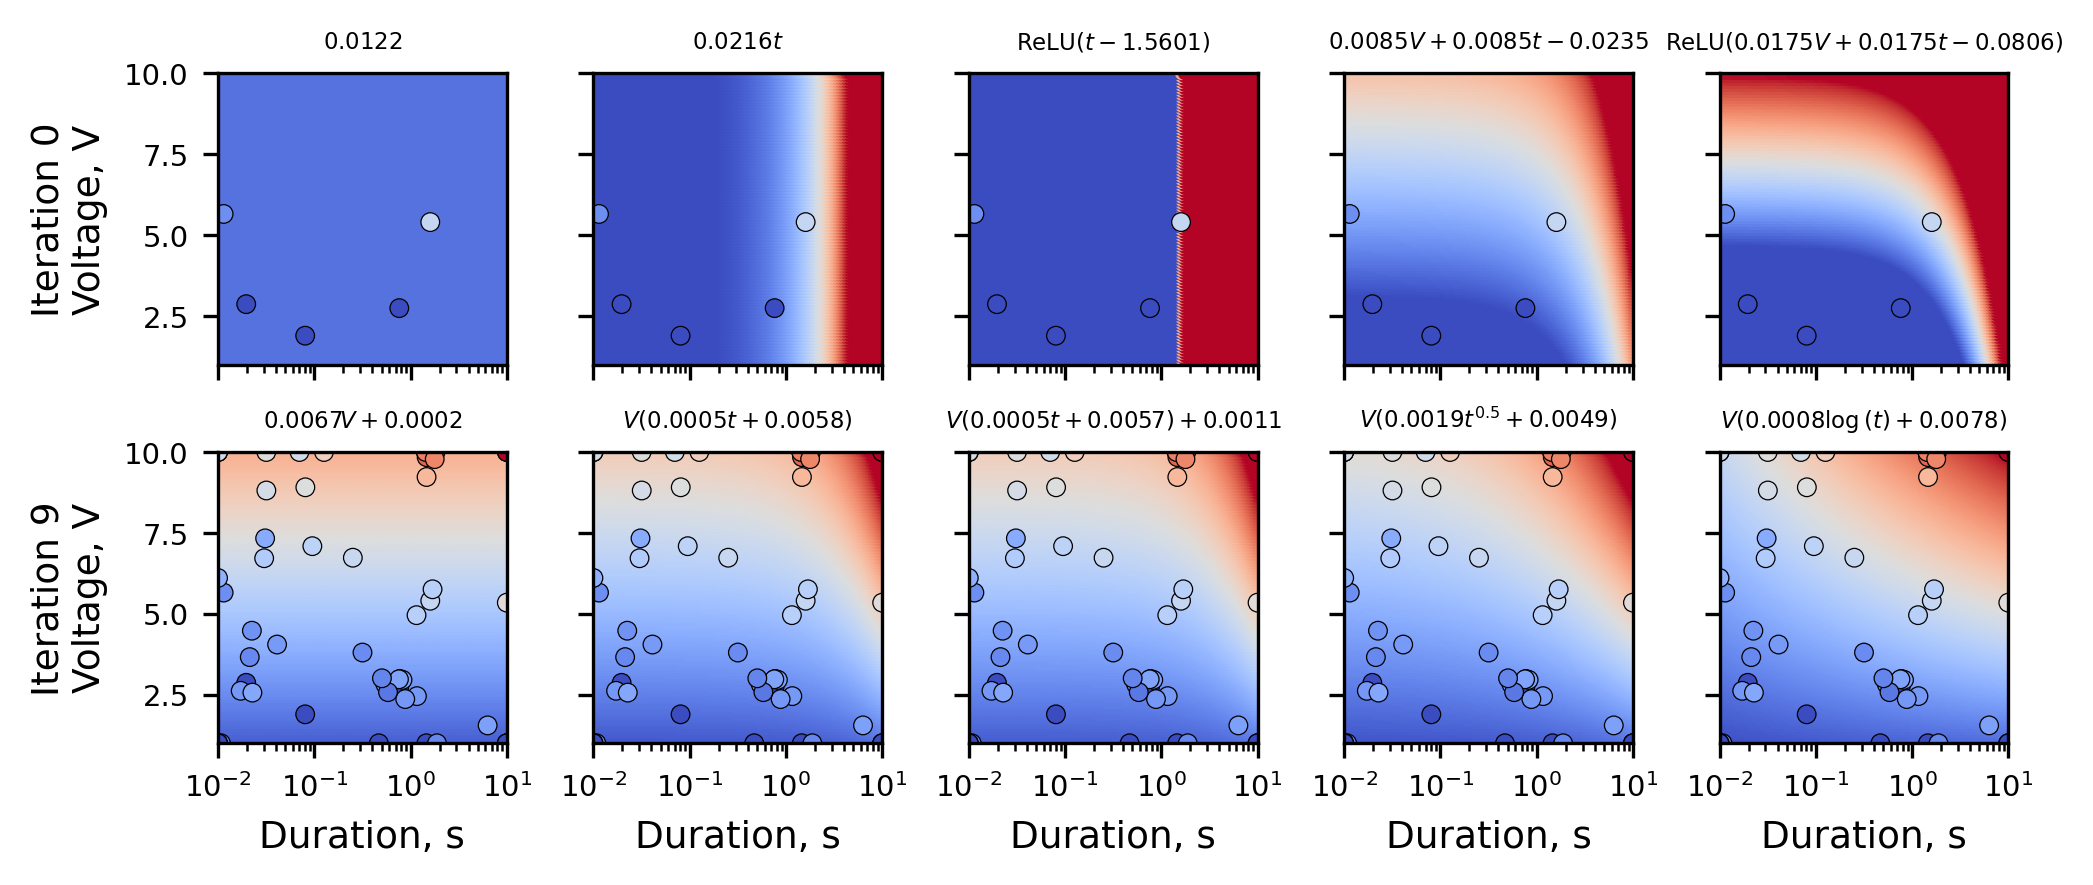

In [30]:
f = make_symbolic_model(models[-1][-1])
pred_l = f(*X_grid.T)

iterr = ['Iteration 0', 'Iteration 9']

fig, ax = plt.subplots(2, 5, figsize=(7.7,2.9), dpi=300, sharey=True, sharex=True)
fig.subplots_adjust(wspace=0.3, hspace=0.3)

for i, m in enumerate(models[0]):
  f = make_symbolic_model(m)
  pred = f(*X_grid.T)
  if type(pred) == float:
    pred = np.ones(len(X_grid))*pred

  ax[0,i].scatter(
    X_grid[:, 0], X_grid[:, 1],
    c=pred,
    s=5,
    cmap='coolwarm',
    vmin=np.min(pred_l),
    vmax=np.max(pred_l))
  ax[0,i].set_xscale('log')

  im2 = ax[0,i].scatter(
    X[:5, 0], X[:5, 1],
    c=R[:5],
    s=20, lw=0.3, ec='k',
    cmap='coolwarm',
    vmin=np.min(pred_l),
    vmax=np.max(pred_l)
  )
  eqs = res['SR_equations'][0][i]
  label = make_label(eqs, ndigits=4)
  ax[0,i].set_title(f'{label}', fontsize=5.5)


for i, m in enumerate(models[-1][2:]):
  f = make_symbolic_model(m)
  pred = f(*X_grid.T)
  if type(pred) == float:
    pred = np.ones(len(X_grid))*pred

  ax[1,i].scatter(
    X_grid[:, 0], X_grid[:, 1],
    c=pred,
    s=5,
    cmap='coolwarm',
    vmin=np.min(pred_l),
    vmax=np.max(pred_l))
  ax[1,i].set_xscale('log')

  im2 = ax[1,i].scatter(
    X[:, 0], X[:, 1],
    c=R,
    s=20, lw=0.3, ec='k',
    cmap='coolwarm',
    vmin=np.min(pred_l),
    vmax=np.max(pred_l)
  )

  eqs = res['SR_equations'][-1][i+2]
  label = make_label(eqs, ndigits=4)
  ax[1,i].set_title(f'{label}', fontsize=5.5)

for _ in ax.flatten():
  _.set_ylim(1, 10)
  _.set_xlim(1e-2, 10)
  _.tick_params(axis='both', labelsize=7)

for _ in ax[1]:
  _.set_xlabel('Duration, s', fontsize=9)

for i, _ in enumerate(ax[:,0]):
  _.set_ylabel(f'{iterr[i]}\nVoltage, V', fontsize=9)


fig.savefig('fig_n.jpg', dpi=300, bbox_inches='tight')


In [155]:
label = make_label(eqs, ndigits=4)

In [156]:
eqs

'(((x0 * 0.00051749835) - -0.005654421) * x1) + 0.0010969313'

In [119]:
X_grid

array([[ 0.01      ,  1.        ],
       [ 0.01072267,  1.        ],
       [ 0.01149757,  1.        ],
       ...,
       [ 8.69749003, 10.        ],
       [ 9.32603347, 10.        ],
       [10.        , 10.        ]])

In [ ]:
print(res['scan_names'])

['PZT_0135', 'PZT_0138', 'PZT_0141', 'PZT_0144', 'PZT_0147', 'PZT_0150', 'PZT_0153', 'PZT_0156', 'PZT_0159', 'PZT_0162', 'PZT_0165', 'PZT_0168', 'PZT_0171', 'PZT_0174', 'PZT_0177', 'PZT_0180', 'PZT_0183', 'PZT_0186', 'PZT_0189', 'PZT_0192', 'PZT_0195', 'PZT_0198', 'PZT_0201', 'PZT_0204', 'PZT_0207', 'PZT_0210', 'PZT_0213', 'PZT_0216', 'PZT_0219', 'PZT_0222', 'PZT_0225', 'PZT_0228', 'PZT_0231', 'PZT_0234', 'PZT_0237', 'PZT_0240', 'PZT_0243', 'PZT_0246', 'PZT_0249', 'PZT_0252', 'PZT_0255', 'PZT_0258', 'PZT_0261', 'PZT_0264', 'PZT_0267', 'PZT_0270', 'PZT_0273', 'PZT_0276', 'PZT_0279', 'PZT_0282', 'PZT_0285', 'PZT_0288', 'PZT_0291', 'PZT_0294', 'PZT_0297']


In [49]:
X_early

array([[0.76350815, 2.74595145],
       [1.60245459, 5.40413691],
       [0.08039305, 1.89419331],
       [0.01142933, 5.65569137],
       [0.01961757, 2.86813738]])

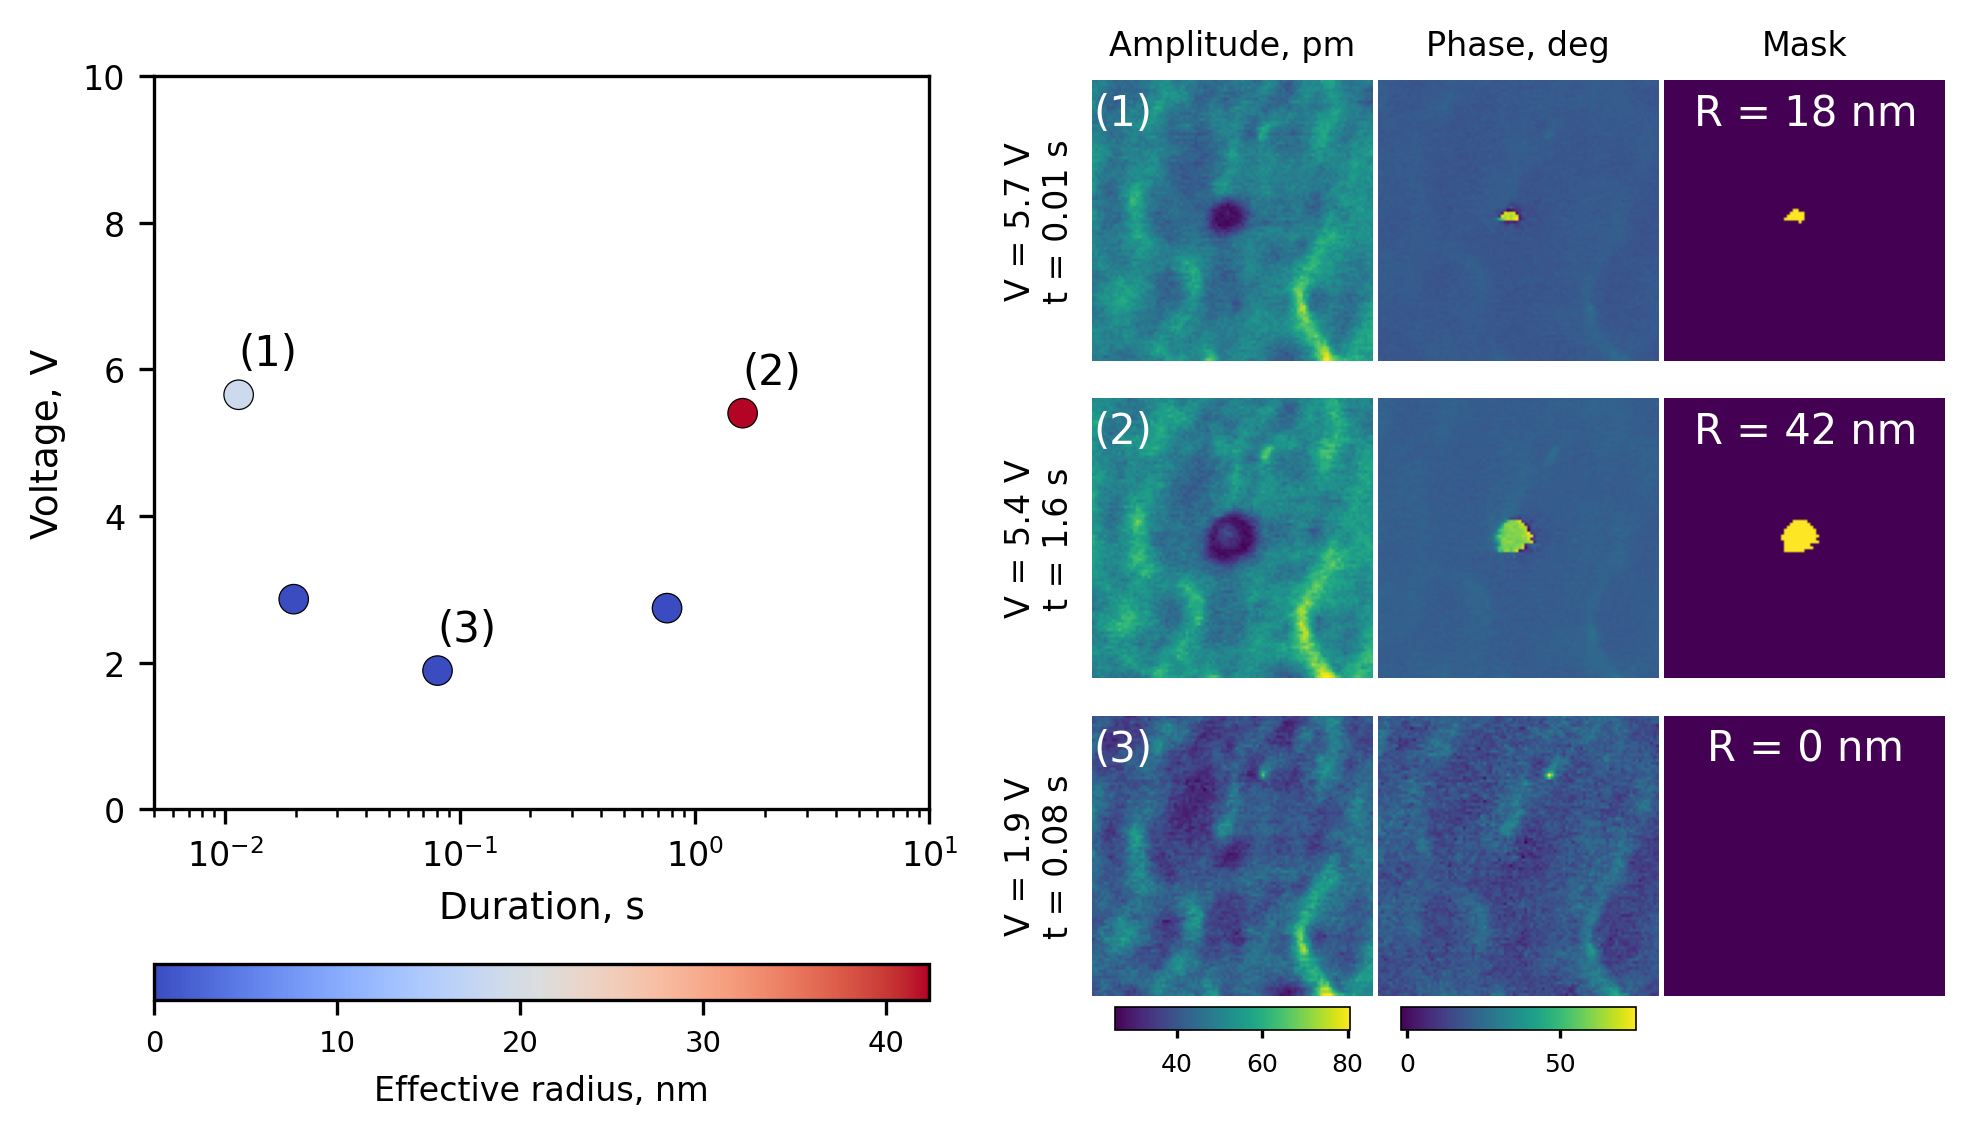

In [103]:
scan_numbers = [3, 1, 2]

fig = plt.figure(figsize=(7.7, 4), dpi=300)

# Outer grid
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.2)

# =========================
# LEFT: scatter + colorbar
# =========================
gs_left = gs[0].subgridspec(2, 1, height_ratios=[10, .5], hspace=0.4)

ax_scatter = fig.add_subplot(gs_left[0])

sc = ax_scatter.scatter(
    X_early[:, 0],
    X_early[:, 1],
    c=R_early * 1e3,
    s=50,
    lw=0.3,
    ec='k',
    cmap='coolwarm',
)

for k, sn in enumerate(scan_numbers):
  ax_scatter.text(X_early[sn, 0], X_early[sn, 1]+.4, s=f'({k+1})')

ax_scatter.set_xlabel('Duration, s', fontsize=9)
ax_scatter.set_ylabel('Voltage, V', fontsize=9)

ax_scatter.set_xscale('log')

# log-safe limits (avoid 0)
xmin = 5e-3#max(np.nanmin(X_early[:, 0]), 1e-6)
ax_scatter.set_xlim(xmin, 10)
ax_scatter.set_ylim(0, 10)

ax_scatter.tick_params(labelsize=8)
#ax_scatter.grid()

# colorbar below
cax = fig.add_subplot(gs_left[1])
cb = fig.colorbar(sc, cax=cax, orientation='horizontal')
cb.set_label("Effective radius, nm", fontsize=8)
cb.ax.tick_params(labelsize=7)

# =========================
# RIGHT: 3x3 grid
# =========================
gs_right = gs[1].subgridspec(3, 3, wspace=0.02, hspace=0.1)

axes = np.empty((3, 3), dtype=object)
ims = np.empty((3, 3), dtype=object)

for i, scan_idx in enumerate(scan_numbers):
    scan_name = res['scan_names'][scan_idx]
    path = os.path.join(folder_scans, f"{scan_name}.ibw")

    dat = at.load_ibw(path)
    bin_mask = res['binary_masks'][scan_idx]

    imgs = [
        dat.data[1]*1e12,   # amplitude
        dat.data[3],   # phase
        bin_mask       # mask
    ]

    for j in range(3):
        ax = fig.add_subplot(gs_right[i, j])
        im = ax.imshow(imgs[j], origin='lower')
        if j ==2:
          ax.text(48, 80, s=f"R = {int(res['eff_radius_m'][scan_idx]*1e9)} nm", c='w', ha='center',)
        if j==0:
          ax.set_ylabel(f"V = {round(X_early[scan_idx, 1],1)} V\nt = {round(X_early[scan_idx, 0],2)} s", fontsize=8)
          ax.text(10, 80, s=f"({i+1})", c='w', ha='center',)

        axes[i, j] = ax
        ims[i, j] = im

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

# titles
axes[0, 0].set_title('Amplitude, pm', fontsize=8)
axes[0, 1].set_title('Phase, deg', fontsize=8)
axes[0, 2].set_title('Mask', fontsize=8)

# =========================
# Colorbars for bottom row (Amplitude & Phase)
# =========================
for j in range(2):
    cax = axes[2, j].inset_axes([0.08, -0.12, 0.84, 0.08])

    cb = fig.colorbar(
        ims[2, j],   # correct mappable
        cax=cax,
        orientation='horizontal'
    )

    cb.ax.tick_params(labelsize=6, length=2)
    cb.outline.set_linewidth(0.4)

plt.show()

fig.savefig('fig3.jpg', dpi=300, bbox_inches='tight')



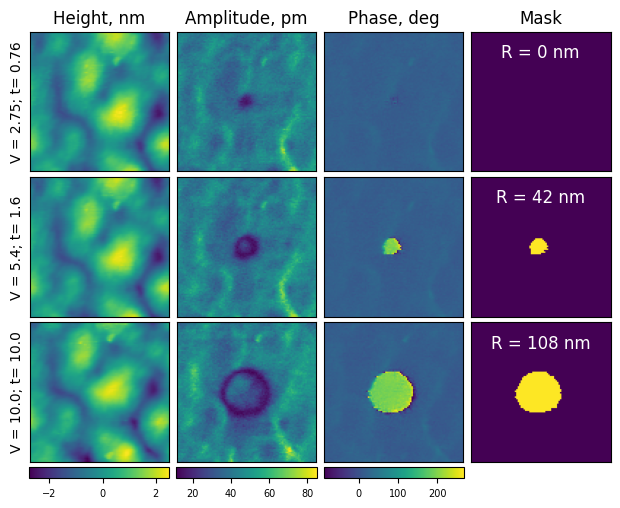

In [80]:
import os
import numpy as np
import matplotlib.pyplot as plt

kk = [0, 1, 8]

fig = plt.figure(figsize=(7.5, 5.8))

# 3 image rows + 1 colorbar row
gs = fig.add_gridspec(
    4, 4,
    height_ratios=[1, 1, 1, 0.08],
    wspace=0.05, hspace=0.05
)

# Image axes
ax = np.empty((3, 4), dtype=object)
for i in range(3):
    for j in range(4):
        ax[i, j] = fig.add_subplot(gs[i, j])

# Colorbar axes (bottom row)
cax = [fig.add_subplot(gs[3, j]) for j in range(3)]

# Load data
loaded = []
for k in kk:
    dat = at.load_ibw(os.path.join(folder_scans, f'{res["scan_names"][k]}.ibw'))
    loaded.append(dat)

# Consistent scaling
height_all = [dat.data[0] for dat in loaded]
amp_all   = [dat.data[1] for dat in loaded]
phase_all = [dat.data[3] for dat in loaded]

vmin_h, vmax_h = np.min([x.min()*1e9 for x in height_all]), np.max([x.max()*1e9 for x in height_all])
vmin_a, vmax_a = np.min([x.min()*1e12 for x in amp_all]),   np.max([x.max()*1e12 for x in amp_all])
vmin_p, vmax_p = np.min([x.min() for x in phase_all]), np.max([x.max() for x in phase_all])

# Plot
ims = [None]*3

for i, (k, dat) in enumerate(zip(kk, loaded)):
    vt = res['param_seq'][k]
    ims[0] = ax[i, 0].imshow(dat.data[0]*1e9, origin='lower', vmin=vmin_h, vmax=vmax_h)
    ims[1] = ax[i, 1].imshow(dat.data[1]*1e12, origin='lower', vmin=vmin_a, vmax=vmax_a)
    ims[2] = ax[i, 2].imshow(dat.data[3], origin='lower', vmin=vmin_p, vmax=vmax_p)

    ax[i, 3].imshow(res['binary_masks'][k], origin='lower')
    ax[i, 3].text(
        0.5, 0.85,
        s=f"R = {int(res['eff_radius_m'][k]*1e9)} nm",
        transform=ax[i, 3].transAxes,
        ha='center', va='center', c='w', fontsize=12
    )
    ax[i,0].set_ylabel(f'V = {round(vt[1], 2)}; t= {round(vt[0], 2)}')

# Titles
ax[0, 0].set_title('Height, nm')
ax[0, 1].set_title('Amplitude, pm')
ax[0, 2].set_title('Phase, deg')
ax[0, 3].set_title('Mask')

# Remove ticks
for a in ax.flatten():
    a.set_xticks([])
    a.set_yticks([])

for j in range(3):
    cb = fig.colorbar(
        ims[j],
        cax=cax[j],
        orientation='horizontal'
    )
    cb.ax.tick_params(labelsize=7)

# Hide last empty bottom cell (under mask)
fig.add_subplot(gs[3, 3]).axis('off')

plt.show()

In [ ]:
dat.size

7e-07

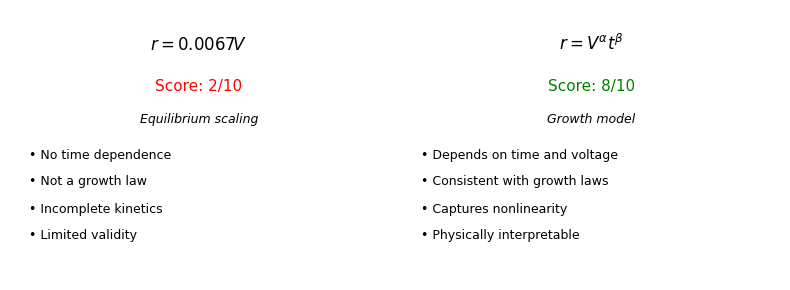

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

def draw_panel(ax, eq, score, model, bullets, color):
    ax.axis('off')

    ax.text(0.5, 0.85, eq, ha='center', fontsize=12, fontweight='bold')
    ax.text(0.5, 0.70, f"Score: {score}/10", ha='center', fontsize=11, color=color)

    ax.text(0.5, 0.58, model, ha='center', fontsize=9, style='italic')

    y = 0.45
    for b in bullets:
        ax.text(0.05, y, f"• {b}", fontsize=9)
        y -= 0.1


# LEFT (bad model)
draw_panel(
    ax[0],
    r"$r = 0.0067 V$",
    2,
    "Equilibrium scaling",
    [
        "No time dependence",
        "Not a growth law",
        "Incomplete kinetics",
        "Limited validity"
    ],
    color='red'
)

# RIGHT (good model)
draw_panel(
    ax[1],
    r"$r = V^\alpha t^\beta$",
    8,
    "Growth model",
    [
        "Depends on time and voltage",
        "Consistent with growth laws",
        "Captures nonlinearity",
        "Physically interpretable"
    ],
    color='green'
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1978/1292818353.py:32: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[0].scatter(*X[nn:nn+5].T, s=25, lw=.3, ec='k', cmap='jet', marker='x', c='k')
/tmp/ipykernel_1978/1292818353.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(*X[nn:nn+5].T, s=25, lw=.3, ec='k', cmap='jet', marker='x', c='k')


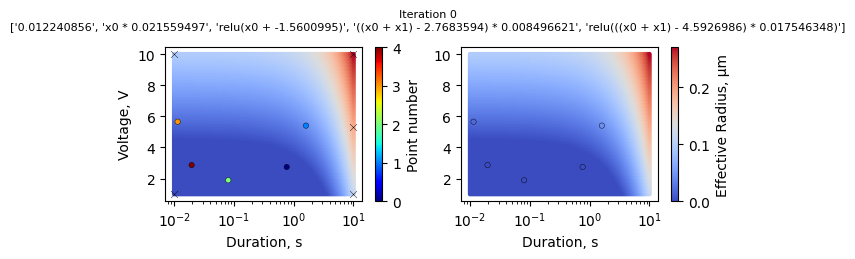

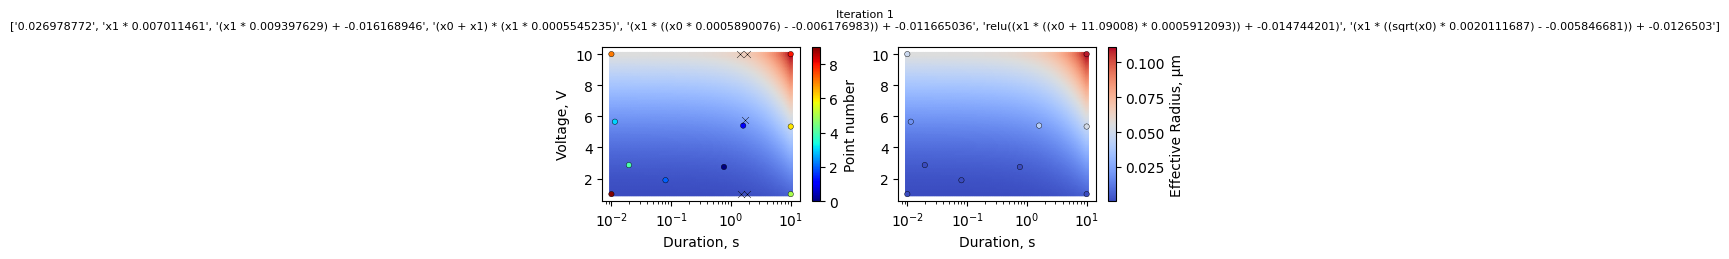

KeyboardInterrupt: 

In [ ]:
figs = []

NN = np.arange(n_iter[0])*pps+n_seeds

for i,nn in enumerate(NN):

  expr = parse_expr(
        models[i][np.argmax(res['SR_score'][i])],
        local_dict={
            'x0': x0,
            'x1': x1,
            'sqrt': sp.sqrt,
            'log': sp.log,
            'relu': relu,
        },
        evaluate=True
    )

  f = lambdify((x0, x1),
               expr, 'numpy')
  pred = f(*X_grid.T)

  fig, ax = plt.subplots(1, 2, figsize=(7,2))

  for _ in ax:
    _.scatter(*X_grid.T, c=pred, s=5, cmap='coolwarm', vmin=np.min(pred), vmax=np.max(pred))
    _.set_xlabel('Duration, s')
    _.set_xscale('log')

  im0 = ax[0].scatter(*X[:nn].T, s=15, lw=.3, ec='k', cmap='jet', c=np.arange(nn))
  cbar = plt.colorbar(im0, label='Point number')
  ax[0].scatter(*X[nn:nn+5].T, s=25, lw=.3, ec='k', cmap='jet', marker='x', c='k')

  im1 = ax[1].scatter(*X[:nn].T, c=R[:nn], s=15, lw=.3, ec='k', cmap='coolwarm', vmin=np.min(pred), vmax=np.max(pred))

  cbar = plt.colorbar(im1, label='Effective Radius, µm')

  ax[0].set_ylabel('Voltage, V')
  fig.suptitle(f"Iteration {i}\n{models[i]}", fontsize=8, y=1.07)
  plt.show()
  figs.append(fig)

In [ ]:
X_grid

array([[ 0.01      ,  1.        ],
       [ 0.01072267,  1.        ],
       [ 0.01149757,  1.        ],
       ...,
       [ 8.69749003, 10.        ],
       [ 9.32603347, 10.        ],
       [10.        , 10.        ]])

In [ ]:
import os

save_dir = "content/images"

# creates all intermediate folders, no error if exists
os.makedirs(save_dir, exist_ok=True)

In [ ]:
import matplotlib.pyplot as plt

def save_image(arr, filename, cmap='gray'):
    path = os.path.join(save_dir, filename)
    plt.imsave(path, arr, cmap=cmap)

for i,fig in enumerate(figs):
  fig.savefig(os.path.join(save_dir, f"iter_{i}.jpg"), dpi=300, bbox_inches='tight')

In [ ]:
import os
import numpy as np
import imageio
import matplotlib.pyplot as plt

def figs_to_gif_stream(figures, gif_path, fps=5):
    with imageio.get_writer(gif_path, mode='I', fps=fps) as writer:
        for fig in figures:
            fig.canvas.draw()
            img = np.asarray(fig.canvas.buffer_rgba())[..., :3]
            writer.append_data(img.copy())
            plt.close(fig)

In [ ]:
import numpy as np
import imageio
import matplotlib.pyplot as plt

def figs_to_gif(figures, gif_path, fps=5, tight=True, pad=1):
    with imageio.get_writer(gif_path, mode='I', fps=fps) as writer:
        for fig in figures:
            if tight:
                fig.tight_layout(pad=pad)

            fig.canvas.draw()

            img = np.asarray(fig.canvas.buffer_rgba())[..., :3]
            writer.append_data(img.copy())

            plt.close(fig)

In [ ]:
figs_to_gif(figs, os.path.join(save_dir, f"gif_file.gif"), fps=1)